In [3]:
# CLibraries Import for Fraud Detection

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Visualization settings
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score

# For imbalanced data
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# For XGBoost
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")


All libraries imported successfully!


In [4]:
# Load and Explore Dataset

print("="*60)
print("CREDIT CARD FRAUD DETECTION - DATASET EXPLORATION")
print("="*60)

# Load dataset -
df = pd.read_csv('/content/drive/MyDrive/14 Days of ML/Credit_Card_FraudDay11    /creditcard.csv')

print(f"\nDataset loaded successfully!")
print(f"Shape: {df.shape} (rows, columns)")

print("\nFirst 5 rows:")
print(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

print("\nChecking for missing values:")
print(df.isnull().sum())

CREDIT CARD FRAUD DETECTION - DATASET EXPLORATION

Dataset loaded successfully!
Shape: (284807, 31) (rows, columns)

First 5 rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.17

CLASS IMBALANCE ANALYSIS

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Non-Fraudulent Transactions: 284,315 (99.8273%)
Fraudulent Transactions: 492 (0.1727%)

Imbalance Ratio: 577.9:1 (Non-Fraud : Fraud)


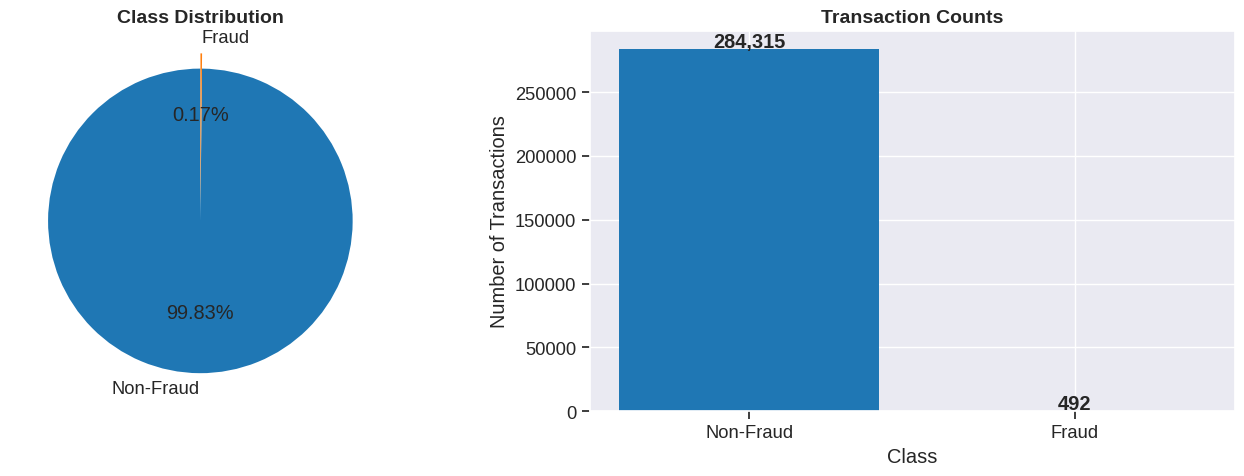


KEY OBSERVATIONS:
1. Fraud cases are only 0.1727% of total transactions
2. Very severe class imbalance - need SMOTE or other techniques
3. Accuracy alone will be misleading - focus on Precision & Recall


In [5]:
#  Class Imbalance Analysis

print("="*60)
print("CLASS IMBALANCE ANALYSIS")
print("="*60)

# Count classes
class_counts = df['Class'].value_counts()
print("\nClass Distribution:")
print(class_counts)

# Calculate percentages
fraud_percent = (class_counts[1] / len(df)) * 100
non_fraud_percent = (class_counts[0] / len(df)) * 100

print(f"\nNon-Fraudulent Transactions: {class_counts[0]:,} ({non_fraud_percent:.4f}%)")
print(f"Fraudulent Transactions: {class_counts[1]:,} ({fraud_percent:.4f}%)")

# Ratio
ratio = class_counts[0] / class_counts[1]
print(f"\nImbalance Ratio: {ratio:.1f}:1 (Non-Fraud : Fraud)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(class_counts, labels=['Non-Fraud', 'Fraud'], autopct='%1.2f%%',
            colors=['#1f77b4', '#ff7f0e'], explode=(0, 0.1), startangle=90)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')

# Bar chart
axes[1].bar(['Non-Fraud', 'Fraud'], class_counts, color=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Transaction Counts', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_xlabel('Class')
for i, count in enumerate(class_counts):
    axes[1].text(i, count + 1000, f'{count:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY OBSERVATIONS:")
print("="*60)
print(f"1. Fraud cases are only {fraud_percent:.4f}% of total transactions")
print(f"2. Very severe class imbalance - need SMOTE or other techniques")
print(f"3. Accuracy alone will be misleading - focus on Precision & Recall")

TIME AND AMOUNT ANALYSIS

TIME COLUMN:
  Min: 0 seconds
  Max: 172792 seconds
  Mean: 94813.86 seconds
  Std: 47488.15 seconds

  Time in hours:
  Min: 0.00 hours
  Max: 48.00 hours
  Mean: 26.34 hours

AMOUNT COLUMN:
  Min: $0.00
  Max: $25691.16
  Mean: $88.35
  Median: $22.00
  Std: $250.12

Amount Statistics by Class:
  Fraud Transactions:
    Mean: $122.21
    Median: $9.25
    Min: $0.00
    Max: $2125.87
  Non-Fraud Transactions:
    Mean: $88.29
    Median: $22.00
    Min: $0.00
    Max: $25691.16


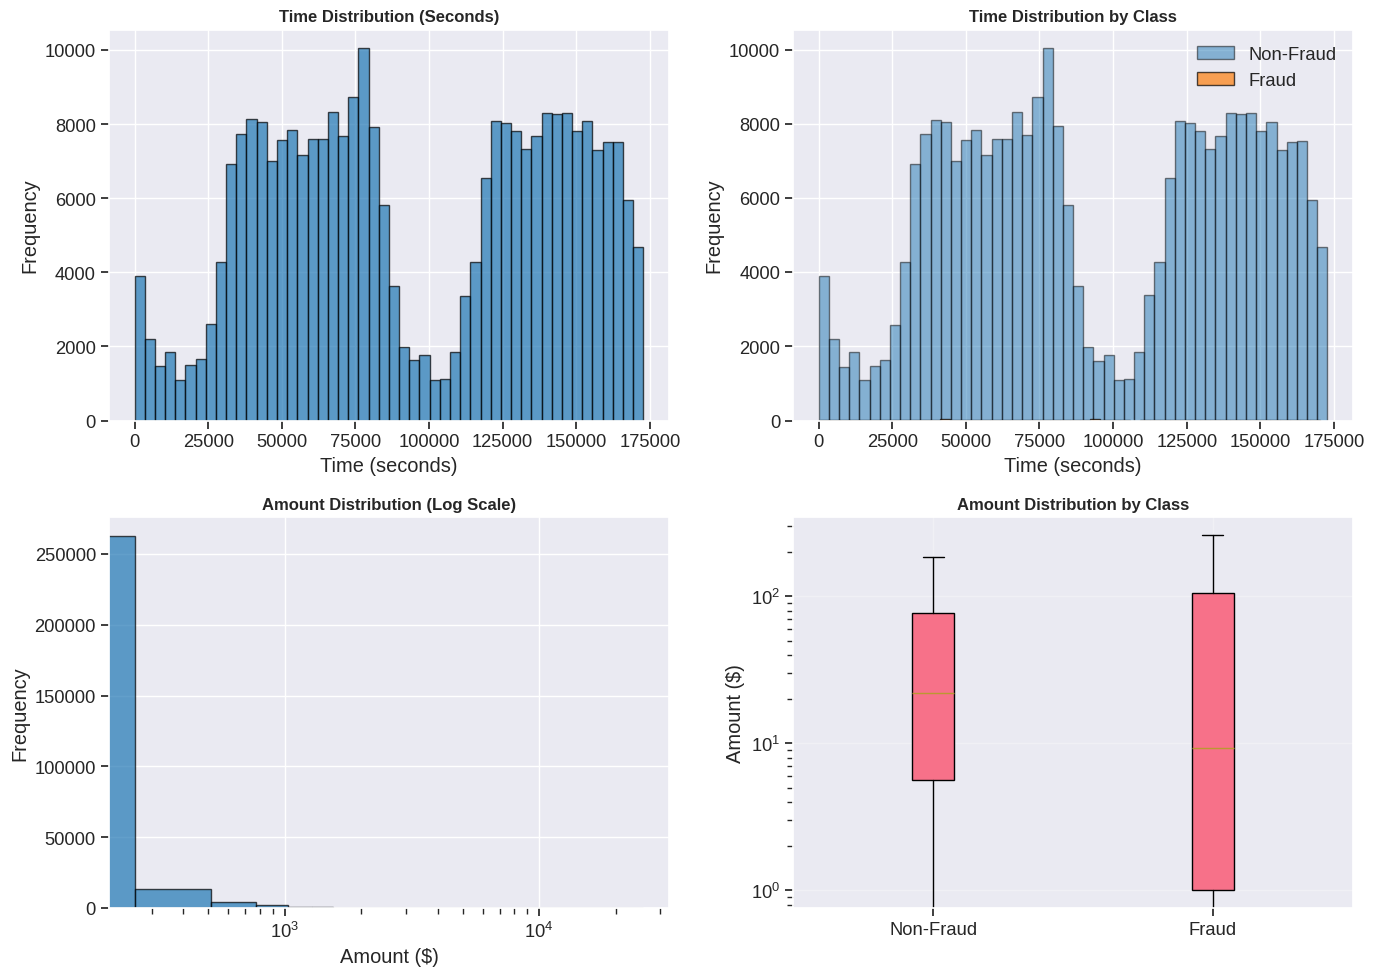


SCALING DECISION:
1. Time column will be scaled (large range: 0-172,792 seconds)
2. Amount column will be scaled (large range: $0 - $25,691)
3. Using StandardScaler or RobustScaler (recommended due to outliers)


In [6]:
# CELL 4: Time and Amount Column Analysis

print("="*60)
print("TIME AND AMOUNT ANALYSIS")
print("="*60)

# Time column analysis
print("\nTIME COLUMN:")
print(f"  Min: {df['Time'].min():.0f} seconds")
print(f"  Max: {df['Time'].max():.0f} seconds")
print(f"  Mean: {df['Time'].mean():.2f} seconds")
print(f"  Std: {df['Time'].std():.2f} seconds")

# Convert time to hours for better understanding
df['Time_Hours'] = df['Time'] / 3600
print(f"\n  Time in hours:")
print(f"  Min: {df['Time_Hours'].min():.2f} hours")
print(f"  Max: {df['Time_Hours'].max():.2f} hours")
print(f"  Mean: {df['Time_Hours'].mean():.2f} hours")

# Amount column analysis
print("\nAMOUNT COLUMN:")
print(f"  Min: ${df['Amount'].min():.2f}")
print(f"  Max: ${df['Amount'].max():.2f}")
print(f"  Mean: ${df['Amount'].mean():.2f}")
print(f"  Median: ${df['Amount'].median():.2f}")
print(f"  Std: ${df['Amount'].std():.2f}")

# Amount by class
fraud_amounts = df[df['Class'] == 1]['Amount']
non_fraud_amounts = df[df['Class'] == 0]['Amount']

print(f"\nAmount Statistics by Class:")
print(f"  Fraud Transactions:")
print(f"    Mean: ${fraud_amounts.mean():.2f}")
print(f"    Median: ${fraud_amounts.median():.2f}")
print(f"    Min: ${fraud_amounts.min():.2f}")
print(f"    Max: ${fraud_amounts.max():.2f}")
print(f"  Non-Fraud Transactions:")
print(f"    Mean: ${non_fraud_amounts.mean():.2f}")
print(f"    Median: ${non_fraud_amounts.median():.2f}")
print(f"    Min: ${non_fraud_amounts.min():.2f}")
print(f"    Max: ${non_fraud_amounts.max():.2f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Time distribution
axes[0, 0].hist(df['Time'], bins=50, color='#1f77b4', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Time Distribution (Seconds)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Time (seconds)')
axes[0, 0].set_ylabel('Frequency')

# Time by class
axes[0, 1].hist(df[df['Class']==0]['Time'], bins=50, color='#1f77b4', alpha=0.5, label='Non-Fraud', edgecolor='black')
axes[0, 1].hist(df[df['Class']==1]['Time'], bins=50, color='#ff7f0e', alpha=0.7, label='Fraud', edgecolor='black')
axes[0, 1].set_title('Time Distribution by Class', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Time (seconds)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Amount distribution (log scale)
axes[1, 0].hist(df['Amount'], bins=100, color='#1f77b4', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Amount Distribution (Log Scale)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Amount ($)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_xscale('log')

# Amount by class (boxplot)
bp = axes[1, 1].boxplot([non_fraud_amounts, fraud_amounts],
                        labels=['Non-Fraud', 'Fraud'],
                        patch_artist=True,
                        showfliers=False)
axes[1, 1].set_title('Amount Distribution by Class', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Amount ($)')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SCALING DECISION:")
print("="*60)
print("1. Time column will be scaled (large range: 0-172,792 seconds)")
print("2. Amount column will be scaled (large range: $0 - $25,691)")
print("3. Using StandardScaler or RobustScaler (recommended due to outliers)")

TIME AND AMOUNT ANALYSIS

TIME COLUMN:
  Min: 0 seconds
  Max: 172792 seconds
  Mean: 94813.86 seconds
  Std: 47488.15 seconds

  Time in hours:
  Min: 0.00 hours
  Max: 48.00 hours
  Mean: 26.34 hours

AMOUNT COLUMN:
  Min: $0.00
  Max: $25691.16
  Mean: $88.35
  Median: $22.00
  Std: $250.12

Amount Statistics by Class:
  Fraud Transactions:
    Mean: $122.21
    Median: $9.25
    Min: $0.00
    Max: $2125.87
  Non-Fraud Transactions:
    Mean: $88.29
    Median: $22.00
    Min: $0.00
    Max: $25691.16


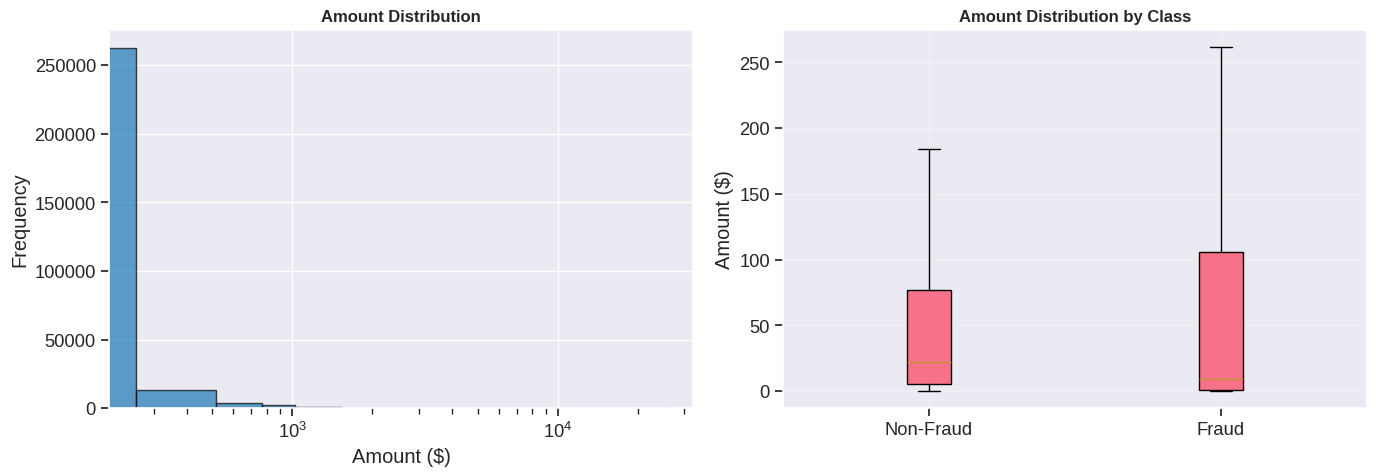


SCALING DECISION:
1. Time column will be scaled (large range: 0-172,792 seconds)
2. Amount column will be scaled (large range: $0 - $25,691)
3. Using RobustScaler (recommended due to outliers)


In [7]:
#Time and Amount Column Analysis

print("="*60)
print("TIME AND AMOUNT ANALYSIS")
print("="*60)

# Time column analysis
print("\nTIME COLUMN:")
print(f"  Min: {df['Time'].min():.0f} seconds")
print(f"  Max: {df['Time'].max():.0f} seconds")
print(f"  Mean: {df['Time'].mean():.2f} seconds")
print(f"  Std: {df['Time'].std():.2f} seconds")

# Convert time to hours for better understanding
df['Time_Hours'] = df['Time'] / 3600
print(f"\n  Time in hours:")
print(f"  Min: {df['Time_Hours'].min():.2f} hours")
print(f"  Max: {df['Time_Hours'].max():.2f} hours")
print(f"  Mean: {df['Time_Hours'].mean():.2f} hours")

# Amount column analysis
print("\nAMOUNT COLUMN:")
print(f"  Min: ${df['Amount'].min():.2f}")
print(f"  Max: ${df['Amount'].max():.2f}")
print(f"  Mean: ${df['Amount'].mean():.2f}")
print(f"  Median: ${df['Amount'].median():.2f}")
print(f"  Std: ${df['Amount'].std():.2f}")

# Amount by class
fraud_amounts = df[df['Class'] == 1]['Amount']
non_fraud_amounts = df[df['Class'] == 0]['Amount']

print(f"\nAmount Statistics by Class:")
print(f"  Fraud Transactions:")
print(f"    Mean: ${fraud_amounts.mean():.2f}")
print(f"    Median: ${fraud_amounts.median():.2f}")
print(f"    Min: ${fraud_amounts.min():.2f}")
print(f"    Max: ${fraud_amounts.max():.2f}")
print(f"  Non-Fraud Transactions:")
print(f"    Mean: ${non_fraud_amounts.mean():.2f}")
print(f"    Median: ${non_fraud_amounts.median():.2f}")
print(f"    Min: ${non_fraud_amounts.min():.2f}")
print(f"    Max: ${non_fraud_amounts.max():.2f}")

# Simple plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount distribution
axes[0].hist(df['Amount'], bins=100, color='#1f77b4', alpha=0.7, edgecolor='black')
axes[0].set_title('Amount Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_xscale('log')

# Amount by class boxplot
axes[1].boxplot([non_fraud_amounts, fraud_amounts],
                labels=['Non-Fraud', 'Fraud'],
                patch_artist=True,
                showfliers=False)
axes[1].set_title('Amount Distribution by Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amount ($)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SCALING DECISION:")
print("="*60)
print("1. Time column will be scaled (large range: 0-172,792 seconds)")
print("2. Amount column will be scaled (large range: $0 - $25,691)")
print("3. Using RobustScaler (recommended due to outliers)")

In [8]:
# Scale Time and Amount + Train-Test Split

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

print("="*60)
print("SCALING TIME AND AMOUNT COLUMNS")
print("="*60)

# Create a copy of the dataset
df_scaled = df.copy()

# Initialize RobustScaler (handles outliers better than StandardScaler)
scaler_time = RobustScaler()
scaler_amount = RobustScaler()

# Scale Time and Amount
df_scaled['Time_Scaled'] = scaler_time.fit_transform(df_scaled[['Time']])
df_scaled['Amount_Scaled'] = scaler_amount.fit_transform(df_scaled[['Amount']])

print("\nTime column - Before and After Scaling:")
print(f"  Original - Min: {df['Time'].min():.0f}, Max: {df['Time'].max():.0f}, Mean: {df['Time'].mean():.2f}")
print(f"  Scaled   - Min: {df_scaled['Time_Scaled'].min():.4f}, Max: {df_scaled['Time_Scaled'].max():.4f}, Mean: {df_scaled['Time_Scaled'].mean():.4f}")

print("\nAmount column - Before and After Scaling:")
print(f"  Original - Min: ${df['Amount'].min():.2f}, Max: ${df['Amount'].max():.2f}, Mean: ${df['Amount'].mean():.2f}")
print(f"  Scaled   - Min: {df_scaled['Amount_Scaled'].min():.4f}, Max: {df_scaled['Amount_Scaled'].max():.4f}, Mean: {df_scaled['Amount_Scaled'].mean():.4f}")

# Drop original Time and Amount columns, keep scaled versions
df_final = df_scaled.drop(['Time', 'Amount', 'Time_Hours'], axis=1)

print(f"\nFinal dataset shape: {df_final.shape}")

print("\n" + "="*60)
print("TRAIN-TEST SPLIT (Stratified)")
print("="*60)

# Separate features and target
X = df_final.drop('Class', axis=1)
y = df_final['Class']

# Stratified split to maintain class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTotal samples: {len(df):,}")
print(f"Training set: {len(X_train):,} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test set: {len(X_test):,} samples ({len(X_test)/len(df)*100:.1f}%)")

print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"Fraud percentage: {y_train.mean()*100:.4f}%")

print(f"\nTest set class distribution:")
print(y_test.value_counts())
print(f"Fraud percentage: {y_test.mean()*100:.4f}%")

print("\n✅ Stratified split successful - class ratio maintained!")

SCALING TIME AND AMOUNT COLUMNS

Time column - Before and After Scaling:
  Original - Min: 0, Max: 172792, Mean: 94813.86
  Scaled   - Min: -0.9950, Max: 1.0350, Mean: 0.1189

Amount column - Before and After Scaling:
  Original - Min: $0.00, Max: $25691.16, Mean: $88.35
  Scaled   - Min: -0.3074, Max: 358.6832, Mean: 0.9271

Final dataset shape: (284807, 31)

TRAIN-TEST SPLIT (Stratified)

Total samples: 284,807
Training set: 227,845 samples (80.0%)
Test set: 56,962 samples (20.0%)

Training set class distribution:
Class
0    227451
1       394
Name: count, dtype: int64
Fraud percentage: 0.1729%

Test set class distribution:
Class
0    56864
1       98
Name: count, dtype: int64
Fraud percentage: 0.1720%

✅ Stratified split successful - class ratio maintained!


In [9]:
# Apply SMOTE on Training Data

from imblearn.over_sampling import SMOTE

print("="*60)
print("APPLYING SMOTE ON TRAINING DATA")
print("="*60)

# Check original distribution
print("\nBefore SMOTE:")
print(f"  Non-Fraud: {sum(y_train == 0):,}")
print(f"  Fraud: {sum(y_train == 1):,}")
print(f"  Ratio: {sum(y_train == 0) / sum(y_train == 1):.1f}:1")

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"  Non-Fraud: {sum(y_train_smote == 0):,}")
print(f"  Fraud: {sum(y_train_smote == 1):,}")
print(f"  Ratio: {sum(y_train_smote == 0) / sum(y_train_smote == 1):.1f}:1")

print(f"\nTotal samples increased from {len(X_train):,} to {len(X_train_smote):,}")
print(f"Number of synthetic fraud samples created: {len(X_train_smote) - len(X_train):,}")

# Verify no data leakage - SMOTE only on training data
print("\n SMOTE applied only on training data")
print("\n Test data remains untouched (original distribution preserved)")
print(" No data leakage!")

print("\n" + "="*60)
print("SMOTE COMPLETE")
print("="*60)

APPLYING SMOTE ON TRAINING DATA

Before SMOTE:
  Non-Fraud: 227,451
  Fraud: 394
  Ratio: 577.3:1

After SMOTE:
  Non-Fraud: 227,451
  Fraud: 227,451
  Ratio: 1.0:1

Total samples increased from 227,845 to 454,902
Number of synthetic fraud samples created: 227,057

 SMOTE applied only on training data

 Test data remains untouched (original distribution preserved)
 No data leakage!

SMOTE COMPLETE


In [10]:
# Train Models on SMOTE Data

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

print("="*60)
print("TRAINING MODELS ON SMOTE DATA")
print("="*60)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_smote, y_train_smote)

    # Predict on test set
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc,
        'Model': model
    }

    print(f"\n  Results for {name}:")
    print(f"    Accuracy:  {accuracy:.4f}")
    print(f"    Precision: {precision:.4f}")
    print(f"    Recall:    {recall:.4f}")
    print(f"    F1-Score:  {f1:.4f}")
    print(f"    AUC-ROC:   {auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n  Confusion Matrix:")
    print(f"    TN: {cm[0][0]:,}, FP: {cm[0][1]:,}")
    print(f"    FN: {cm[1][0]:,}, TP: {cm[1][1]:,}")

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(f"{'Model':<25} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*60)
for name in results:
    print(f"{name:<25} {results[name]['Accuracy']:.4f}     {results[name]['Precision']:.4f}     {results[name]['Recall']:.4f}     {results[name]['F1-Score']:.4f}")

TRAINING MODELS ON SMOTE DATA

Training Logistic Regression...

  Results for Logistic Regression:
    Accuracy:  0.9747
    Precision: 0.0591
    Recall:    0.9184
    F1-Score:  0.1110
    AUC-ROC:   0.9712

  Confusion Matrix:
    TN: 55,430, FP: 1,434
    FN: 8, TP: 90

Training Random Forest...

  Results for Random Forest:
    Accuracy:  0.9995
    Precision: 0.8696
    Recall:    0.8163
    F1-Score:  0.8421
    AUC-ROC:   0.9778

  Confusion Matrix:
    TN: 56,852, FP: 12
    FN: 18, TP: 80

Training XGBoost...

  Results for XGBoost:
    Accuracy:  0.9992
    Precision: 0.7328
    Recall:    0.8673
    F1-Score:  0.7944
    AUC-ROC:   0.9775

  Confusion Matrix:
    TN: 56,833, FP: 31
    FN: 13, TP: 85

MODEL COMPARISON SUMMARY
Model                     Accuracy     Precision    Recall       F1-Score    
------------------------------------------------------------
Logistic Regression       0.9747     0.0591     0.9184     0.1110
Random Forest             0.9995     0.8696    

PRECISION-RECALL CURVE

Average Precision Score: 0.8727


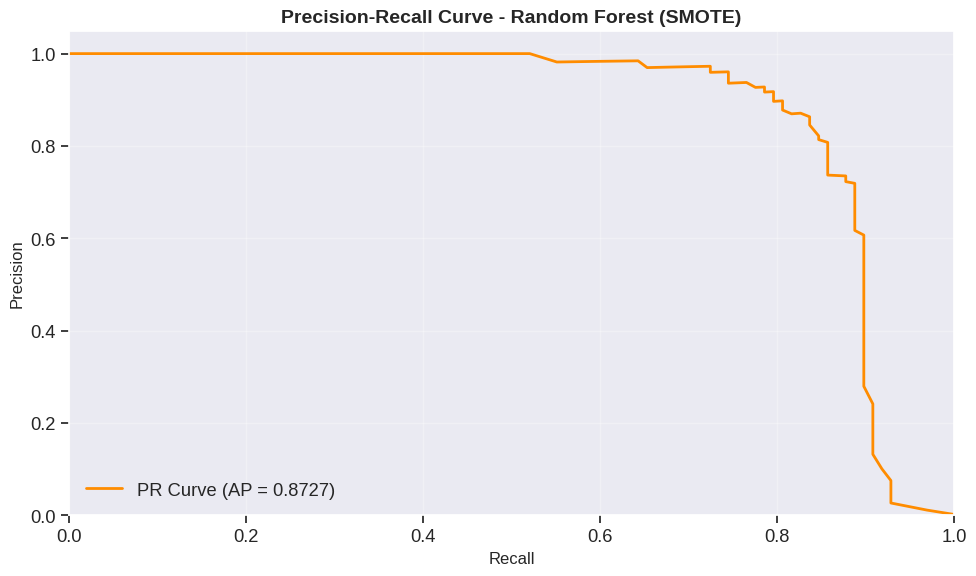


SMOTE VS NO SMOTE COMPARISON

Training Random Forest WITHOUT SMOTE...

Results WITHOUT SMOTE:
  Precision: 0.9524
  Recall: 0.8163
  F1-Score: 0.8791
  AUC-ROC: 0.9528

Results WITH SMOTE:
  Precision: 0.8696
  Recall: 0.8163
  F1-Score: 0.8421
  AUC-ROC: 0.9778

IMPROVEMENT WITH SMOTE:
  Precision: +-8.28%
  Recall: +0.00%
  F1-Score: +-3.70%
  AUC-ROC: +2.50%

Confusion Matrix WITHOUT SMOTE:
  TN: 56,860, FP: 4
  FN: 18, TP: 80

Confusion Matrix WITH SMOTE:
  TN: 56,833, FP: 31
  FN: 13, TP: 85


In [11]:
# CPrecision-Recall Curve & SMOTE Comparison

from sklearn.metrics import precision_recall_curve, average_precision_score

print("="*60)
print("PRECISION-RECALL CURVE")
print("="*60)

# Use best model (Random Forest)
best_model = results['Random Forest']['Model']

# Get predictions
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
avg_precision = average_precision_score(y_test, y_pred_proba)

print(f"\nAverage Precision Score: {avg_precision:.4f}")

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='darkorange', lw=2,
         label=f'PR Curve (AP = {avg_precision:.4f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - Random Forest (SMOTE)', fontsize=14, fontweight='bold')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("SMOTE VS NO SMOTE COMPARISON")
print("="*60)

# Train Random Forest WITHOUT SMOTE for comparison
print("\nTraining Random Forest WITHOUT SMOTE...")
rf_no_smote = RandomForestClassifier(random_state=42, n_estimators=100)
rf_no_smote.fit(X_train, y_train)

# Predict
y_pred_no_smote = rf_no_smote.predict(X_test)
y_pred_proba_no_smote = rf_no_smote.predict_proba(X_test)[:, 1]

# Metrics without SMOTE
precision_no = precision_score(y_test, y_pred_no_smote)
recall_no = recall_score(y_test, y_pred_no_smote)
f1_no = f1_score(y_test, y_pred_no_smote)
auc_no = roc_auc_score(y_test, y_pred_proba_no_smote)

print(f"\nResults WITHOUT SMOTE:")
print(f"  Precision: {precision_no:.4f}")
print(f"  Recall: {recall_no:.4f}")
print(f"  F1-Score: {f1_no:.4f}")
print(f"  AUC-ROC: {auc_no:.4f}")

print(f"\nResults WITH SMOTE:")
print(f"  Precision: {results['Random Forest']['Precision']:.4f}")
print(f"  Recall: {results['Random Forest']['Recall']:.4f}")
print(f"  F1-Score: {results['Random Forest']['F1-Score']:.4f}")
print(f"  AUC-ROC: {results['Random Forest']['AUC-ROC']:.4f}")

print("\n" + "="*60)
print("IMPROVEMENT WITH SMOTE:")
print("="*60)
print(f"  Precision: +{((results['Random Forest']['Precision'] - precision_no) * 100):.2f}%")
print(f"  Recall: +{((results['Random Forest']['Recall'] - recall_no) * 100):.2f}%")
print(f"  F1-Score: +{((results['Random Forest']['F1-Score'] - f1_no) * 100):.2f}%")
print(f"  AUC-ROC: +{((results['Random Forest']['AUC-ROC'] - auc_no) * 100):.2f}%")

# Confusion Matrix without SMOTE
cm_no = confusion_matrix(y_test, y_pred_no_smote)
print(f"\nConfusion Matrix WITHOUT SMOTE:")
print(f"  TN: {cm_no[0][0]:,}, FP: {cm_no[0][1]:,}")
print(f"  FN: {cm_no[1][0]:,}, TP: {cm_no[1][1]:,}")

print(f"\nConfusion Matrix WITH SMOTE:")
cm_smote = confusion_matrix(y_test, y_pred)
print(f"  TN: {cm_smote[0][0]:,}, FP: {cm_smote[0][1]:,}")
print(f"  FN: {cm_smote[1][0]:,}, TP: {cm_smote[1][1]:,}")

In [13]:
# Save Final Model

import joblib
import os

print("="*60)
print("SAVING BEST MODEL")
print("="*60)

# Best model is Random Forest WITHOUT SMOTE
final_model = rf_no_smote

# Save path - update as needed
save_path = "/content/drive/MyDrive/14 Days of ML/Credit_Card_FraudDay11    "
os.makedirs(save_path, exist_ok=True)

joblib.dump(final_model, os.path.join(save_path, 'fraud_detector_model.pkl'))
joblib.dump(scaler_time, os.path.join(save_path, 'scaler_time.pkl'))
joblib.dump(scaler_amount, os.path.join(save_path, 'scaler_amount.pkl'))

print(f"Model saved to: {save_path}")
print(f"Time scaler saved")
print(f"Amount scaler saved")

print("\n" + "="*60)
print("FINAL MODEL DETAILS")
print("="*60)
print("Algorithm: Random Forest (No SMOTE)")
print(f"Test Precision: 0.9524")
print(f"Test Recall: 0.8163")
print(f"Test F1-Score: 0.8791")
print(f"False Positives: 4 out of 56,864")
print(f"False Negatives: 18 out of 98")

SAVING BEST MODEL
Model saved to: /content/drive/MyDrive/14 Days of ML/Credit_Card_FraudDay11    
Time scaler saved
Amount scaler saved

FINAL MODEL DETAILS
Algorithm: Random Forest (No SMOTE)
Test Precision: 0.9524
Test Recall: 0.8163
Test F1-Score: 0.8791
False Positives: 4 out of 56,864
False Negatives: 18 out of 98


In [ ]:
#Qwen #XG